# Source-Space RSA — Brain Visualisation

Loads per-subject source RSA maps (morphed to fsaverage) and group noise ceiling
from the HPC share and creates publication-quality brain plots.

**Workflow:**
1. Load per-subject morphed `.stc` files and compute group average
2. Optionally load noise ceiling STC and compute RSA / noise ceiling ratio
3. Plot brain maps (lateral / medial, pial / inflated)
4. Save standalone colorbar
5. Subject consistency check

Run `compute_source_rsa.py` on the HPC first to produce the `.stc` files.

In [62]:
import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import mne

sns.set_context('poster')
plt.rcParams['svg.fonttype'] = 'none'

print('Libraries loaded.')

Libraries loaded.


## Configuration

In [88]:
# ── Subject / model parameters ────────────────────────────────────────────────
subjects   = [1, 2, 3, 4, 5]
model_name = 'resnet50_ecoset_crop'
layer      = 'layer3'                                    # single layer for RSA maps
layers     = ['layer1', 'layer2', 'layer3', 'layer4', 'avgpool']   # all layers for WTA map

# ── SSH-mount paths ───────────────────────────────────────────────────────────
avs_dir   = '/Users/atlas/avs'
share_dir = '/Users/atlas/share_psulewski/psulewski'

subjects_dir = f'{avs_dir}/rawdir/'   # FreeSurfer subjects dir
rsa_dir      = f'{share_dir}/pyavs/source_rsa/'
morph_to     = 'fsaverage'

# ── Output ────────────────────────────────────────────────────────────────────
output_dir = os.path.join(share_dir, 'pyavs', 'source_rsa_figures',
                          f'model-{model_name}_layer-{layer}')
os.makedirs(output_dir, exist_ok=True)

# ── Visualisation parameters ──────────────────────────────────────────────────
surfaces = ['pial']
views    = ['lateral', 'medial']

colormap = 'magma'

# Color limits for Pearson r (set vmax=None for auto from 99th percentile)
vmin = 0.0
vmid = None   # None → auto midpoint
vmax = None # None → auto 99th percentile of group average

print(f'Model: {model_name}  Layer: {layer}')
print(f'Layers (WTA): {layers}')
print(f'Subjects: {subjects}')
print(f'RSA dir: {rsa_dir}')
print(f'Output:  {output_dir}')

Model: resnet50_ecoset_crop  Layer: layer3
Layers (WTA): ['layer1', 'layer2', 'layer3', 'layer4', 'avgpool']
Subjects: [1, 2, 3, 4, 5]
RSA dir: /Users/atlas/share_psulewski/psulewski/pyavs/source_rsa/
Output:  /Users/atlas/share_psulewski/psulewski/pyavs/source_rsa_figures/model-resnet50_ecoset_crop_layer-layer3


## Function Definitions

In [89]:
def load_subject_rsa_stc(subject_id, rsa_dir, model_name, layer):
    """Load a morphed source RSA map for one subject."""
    fname = os.path.join(
        rsa_dir,
        f'sub-{subject_id:02d}',
        f'sub-{subject_id:02d}_model-{model_name}_layer-{layer}_source_rsa',
    )
    if not (os.path.exists(fname + '-lh.stc') and
            os.path.exists(fname + '-rh.stc')):
        print(f'  WARNING: STC not found for sub-{subject_id:02d} — skipping.')
        return None
    stc = mne.read_source_estimate(fname)
    print(f'  sub-{subject_id:02d}: {stc.data.shape[0]} vertices, '
          f'r range [{stc.data.min():.3f}, {stc.data.max():.3f}]')
    return stc


def load_noise_ceiling_stc(rsa_dir, model_name, layer):
    """Load group noise ceiling lower-bound STC."""
    fname = os.path.join(
        rsa_dir,
        f'group_model-{model_name}_layer-{layer}_noise_ceiling_lower',
    )
    if not (os.path.exists(fname + '-lh.stc') and
            os.path.exists(fname + '-rh.stc')):
        print('WARNING: noise ceiling STC not found.')
        return None
    stc = mne.read_source_estimate(fname)
    print(f'Noise ceiling: {stc.data.shape[0]} vertices, '
          f'range [{stc.data.min():.3f}, {stc.data.max():.3f}]')
    return stc


def compute_group_average(stcs):
    """Average source estimates across subjects."""
    data_stack = np.stack([s.data for s in stcs], axis=0)   # (n_subs, n_verts, 1)
    avg_data   = np.mean(data_stack, axis=0)
    avg_stc    = stcs[0].copy()
    avg_stc.data = avg_data
    return avg_stc


def auto_clim(stc, vmin=0.0, quantile=0.99):
    """Derive color limits from the STC data."""
    vals = stc.data.ravel()
    vmax = float(np.quantile(vals, quantile))
    vmid = (vmin + vmax) / 2
    return vmin, vmid, vmax


def plot_brain(
    stc, surface, view,
    subjects_dir, morph_to, colormap,
    vmin, vmid, vmax,
    save_path=None,
):
    """
    Render a brain plot for a single-timepoint STC.

    Parameters
    ----------
    stc : mne.SourceEstimate
    surface : str
        'pial' or 'inflated'
    view : str
        'lateral' or 'medial'
    subjects_dir, morph_to, colormap : str
    vmin, vmid, vmax : float
    save_path : str or None
        Path without extension — saves .png if provided.

    Returns
    -------
    mne.viz.Brain
    """
    brain = stc.plot(
        subject=morph_to,
        subjects_dir=subjects_dir,
        initial_time=stc.tmin,
        hemi='split',
        time_viewer=False,
        colorbar=False,
        colormap=colormap,
        clim=dict(kind='value', lims=[vmin, vmid, vmax]),
        smoothing_steps=3,
        transparent=False,
        surface=surface,
        background='white',
        views=view,
        size=(900, 450),
    )

    if save_path:
        brain.save_image(save_path + '.png')
        print(f'    Saved: {os.path.basename(save_path)}.png')

    return brain


def create_colorbar(vmin, vmid, vmax, colormap, output_dir,
                    label='pearson r', fname='colorbar'):
    """Save a standalone horizontal colorbar figure."""
    plt.figure(figsize=(5.5, 3.4))
    ax = plt.gca()

    mne.viz.plot_brain_colorbar(
        ax,
        clim=dict(kind='value', lims=[vmin, vmid, vmax]),
        colormap=colormap,
        transparent=False,
        orientation='horizontal',
    )

    ticks = np.linspace(vmin, vmax, 3)
    ax.set_xticks(ticks)
    ax.set_xticklabels([f'{t:.2f}' for t in ticks])
    ax.set_xlabel(label)
    ax.tick_params(tick1On=False)

    sns.despine()
    plt.tight_layout()

    for ext in ('png', 'pdf'):
        fpath = os.path.join(output_dir, f'{fname}.{ext}')
        plt.savefig(fpath, dpi=300, bbox_inches='tight',
                    facecolor='white', edgecolor='none')
    plt.show()
    print(f'Colorbar saved to {output_dir}')


print('Functions defined.')

Functions defined.


In [90]:
def load_subject_all_layers_stcs(subject_id, rsa_dir, model_name, layers):
    """Load RSA STCs for all layers for one subject.

    Returns
    -------
    dict mapping layer name -> mne.SourceEstimate, or None for missing layers.
    """
    result = {}
    for lyr in layers:
        stc = load_subject_rsa_stc(subject_id, rsa_dir, model_name, lyr)
        result[lyr] = stc  # None if missing
    return result


def compute_wta_stc(all_layers_stcs, layers):
    """Compute winner-take-all layer map via per-subject WTA + majority vote.

    For each subject, the winning layer at each vertex is determined by argmax
    across layers. The group WTA map is then the majority vote across subjects
    (i.e. the layer that won the most subjects at each vertex).

    Parameters
    ----------
    all_layers_stcs : dict, layer -> list of per-subject mne.SourceEstimate
    layers : list of str

    Returns
    -------
    wta_stc : mne.SourceEstimate
        Integer-valued STC (0-based layer index) in fsaverage space.
    winner_counts : dict
        Number of vertices won by each layer in the group map.
    """
    n_subjects = len(all_layers_stcs[layers[0]])
    n_vertices = all_layers_stcs[layers[0]][0].data.shape[0]

    # win_counts[layer_i, vertex] = number of subjects where layer_i won
    win_counts = np.zeros((len(layers), n_vertices), dtype=int)

    for s in range(n_subjects):
        data_stack = np.stack(
            [all_layers_stcs[lyr][s].data[:, 0] for lyr in layers], axis=0
        )  # (n_layers, n_vertices)
        subject_winner = np.argmax(data_stack, axis=0)  # (n_vertices,)
        for i in range(len(layers)):
            win_counts[i] += (subject_winner == i)

    # Majority vote across subjects
    group_winner = np.argmax(win_counts, axis=0).astype(float)

    wta_stc = all_layers_stcs[layers[0]][0].copy()
    wta_stc.data = group_winner[:, np.newaxis]

    winner_counts = {
        lyr: int((group_winner == i).sum()) for i, lyr in enumerate(layers)
    }
    return wta_stc, winner_counts, win_counts


print('Multi-layer functions defined.')

Multi-layer functions defined.


## Load Per-Subject RSA STCs

In [66]:
print(f'Loading RSA STCs from: {rsa_dir}\n')

stcs = []
loaded_subjects = []

for sub in subjects:
    stc = load_subject_rsa_stc(sub, rsa_dir, model_name, layer)
    if stc is not None:
        stcs.append(stc)
        loaded_subjects.append(sub)

print(f'\nLoaded {len(stcs)}/{len(subjects)} subjects: {loaded_subjects}')

Loading RSA STCs from: /Users/atlas/share_psulewski/psulewski/pyavs/source_rsa/

  sub-01: 20484 vertices, r range [-0.024, 0.485]
  sub-02: 20484 vertices, r range [-0.005, 0.532]
  sub-03: 20484 vertices, r range [-0.016, 0.571]
  sub-04: 20484 vertices, r range [-0.000, 0.495]
  sub-05: 20484 vertices, r range [-0.020, 0.326]

Loaded 5/5 subjects: [1, 2, 3, 4, 5]


## Group Average & Color Limits

In [91]:
if not stcs:
    raise RuntimeError('No STCs loaded — check rsa_dir and run compute_source_rsa.py first.')

avg_stc = compute_group_average(stcs)

print(f'Group average shape: {avg_stc.data.shape}')
print(f'Value range: {avg_stc.data.min():.4f} – {avg_stc.data.max():.4f}')

if vmax is None:
    _vmin, _vmid, _vmax = auto_clim(avg_stc, vmin=vmin)
    print(f'\nAuto color limits: vmin={_vmin:.3f}, vmid={_vmid:.3f}, vmax={_vmax:.3f}')
else:
    _vmin = vmin
    _vmid = vmid if vmid is not None else (vmin + vmax) / 2
    _vmax = vmax
    print(f'\nManual color limits: vmin={_vmin:.3f}, vmid={_vmid:.3f}, vmax={_vmax:.3f}')

Group average shape: (20484, 1)
Value range: 0.0231 – 0.3861

Auto color limits: vmin=0.000, vmid=0.181, vmax=0.363


## Brain Plots — Group Average RSA

One image per `(surface, view)` combination.

In [92]:
print('Generating brain plots (group average RSA)...\n')

for surface in surfaces:
    for view in views:
        fname = f'group_rsa_{surface}_{view}'
        save_path = os.path.join(output_dir, fname)
        try:
            brain = plot_brain(
                stc=avg_stc,
                surface=surface, view=view,
                subjects_dir=subjects_dir, morph_to=morph_to,
                colormap=colormap,
                vmin=_vmin, vmid=_vmid, vmax=_vmax,
                save_path=save_path,
            )
            #brain.close()
        except Exception as e:
            print(f'  ERROR ({surface}, {view}): {e}')

print('\nBrain plots done.')

Generating brain plots (group average RSA)...

    Saved: group_rsa_pial_lateral.png
    Saved: group_rsa_pial_medial.png

Brain plots done.


## Standalone Colorbar

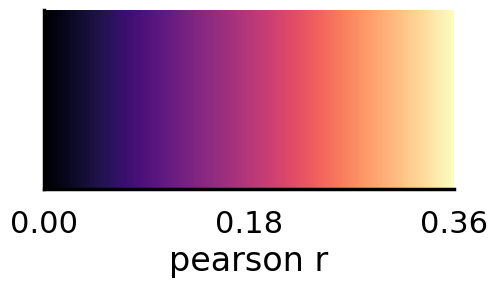

Colorbar saved to /Users/atlas/share_psulewski/psulewski/pyavs/source_rsa_figures/model-resnet50_ecoset_crop_layer-layer3


In [97]:
create_colorbar(
    vmin=_vmin, vmid=_vmid, vmax=_vmax,
    colormap=colormap,
    output_dir=output_dir,
    label='pearson r',
)

## Noise Ceiling

Load the group noise ceiling STC and plot it alongside the RSA map.
Also compute the normalised RSA (RSA / noise ceiling) to show explained variance.

In [99]:
nc_stc = load_noise_ceiling_stc(rsa_dir, model_name, layer)

In [71]:
if nc_stc is not None:
    # ── Brain plot: noise ceiling ────────────────────────────────────────────
    nc_vmin, nc_vmid, nc_vmax = auto_clim(nc_stc, vmin=0.0)
    print(f'Noise ceiling color limits: {nc_vmin:.3f} – {nc_vmax:.3f}\n')

    for surface in surfaces:
        for view in views:
            fname = f'group_noise_ceiling_{surface}_{view}'
            save_path = os.path.join(output_dir, fname)
            try:
                brain = plot_brain(
                    stc=nc_stc,
                    surface=surface, view=view,
                    subjects_dir=subjects_dir, morph_to=morph_to,
                    colormap=colormap,
                    vmin=nc_vmin, vmid=nc_vmid, vmax=nc_vmax,
                    save_path=save_path,
                )
                brain.close()
            except Exception as e:
                print(f'  ERROR ({surface}, {view}): {e}')

    create_colorbar(
        vmin=nc_vmin, vmid=nc_vmid, vmax=nc_vmax,
        colormap=colormap,
        output_dir=output_dir,
        label='noise ceiling lower bound [pearson r]',
        fname='colorbar_noise_ceiling',
    )

    # ── Normalised RSA (RSA / noise ceiling) ────────────────────────────────
    # Mask vertices where noise ceiling ≈ 0 to avoid division artefacts
    nc_data = nc_stc.data.ravel()
    rsa_data = avg_stc.data.ravel()

    norm_data = np.where(
        nc_data > 0.01,
        rsa_data / nc_data,
        0.0,
    )
    norm_stc = avg_stc.copy()
    norm_stc.data = norm_data[:, np.newaxis]

    norm_vmin, norm_vmid, norm_vmax = auto_clim(norm_stc, vmin=0.0)
    print(f'\nNormalised RSA color limits: {norm_vmin:.3f} – {norm_vmax:.3f}')

    for surface in surfaces:
        for view in views:
            fname = f'group_rsa_normalised_{surface}_{view}'
            save_path = os.path.join(output_dir, fname)
            try:
                brain = plot_brain(
                    stc=norm_stc,
                    surface=surface, view=view,
                    subjects_dir=subjects_dir, morph_to=morph_to,
                    colormap=colormap,
                    vmin=norm_vmin, vmid=norm_vmid, vmax=norm_vmax,
                    save_path=save_path,
                )
                brain.close()
            except Exception as e:
                print(f'  ERROR ({surface}, {view}): {e}')

    create_colorbar(
        vmin=norm_vmin, vmid=norm_vmid, vmax=norm_vmax,
        colormap=colormap,
        output_dir=output_dir,
        label='rsa / noise ceiling',
        fname='colorbar_normalised',
    )
else:
    print('Skipping noise ceiling plots (STC not found).')

Skipping noise ceiling plots (STC not found).


## Subject Consistency Check

Distribution of per-subject RSA values across vertices, overlaid with the group average.
Useful for spotting outlier subjects before committing to the full brain render.

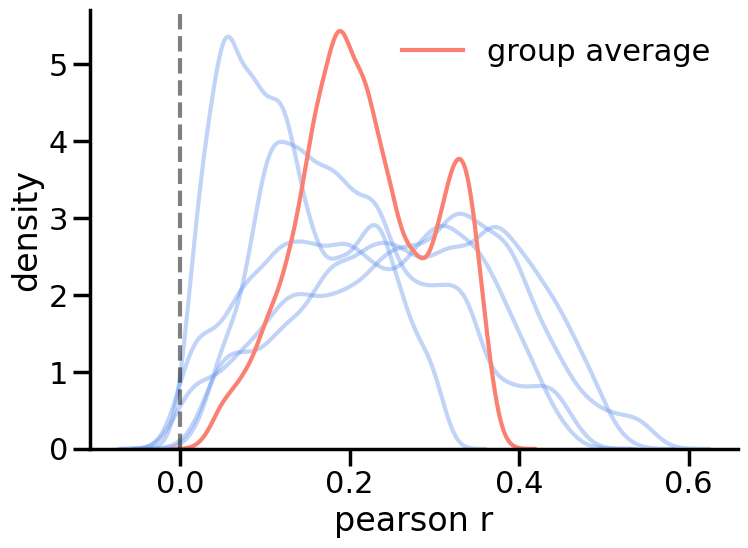

Saved: /Users/atlas/share_psulewski/psulewski/pyavs/source_rsa_figures/model-resnet50_ecoset_crop_layer-layer3/subject_rsa_distributions.png


In [72]:
plt.figure(figsize=(8, 6))

for stc_s, sub in zip(stcs, loaded_subjects):
    vals = stc_s.data.ravel()
    sns.kdeplot(vals, color='cornflowerblue', alpha=0.4)

# Group average on top
sns.kdeplot(avg_stc.data.ravel(), color='salmon', label='group average')

plt.axvline(x=0, color='black', linestyle='--', alpha=0.5)
plt.xlabel('pearson r')
plt.ylabel('density')
plt.legend(frameon=False)
sns.despine()
plt.tight_layout()

fpath = os.path.join(output_dir, 'subject_rsa_distributions')
for ext in ('png', 'pdf'):
    plt.savefig(f'{fpath}.{ext}', dpi=300, bbox_inches='tight',
                facecolor='white', edgecolor='none')
plt.show()
print(f'Saved: {fpath}.png')

## Subject × Vertex Correlation (split-half reliability)

For each pair of subjects, compute the vertex-wise Pearson correlation of their RSA maps.
A high average inter-subject correlation indicates a reliable group pattern.

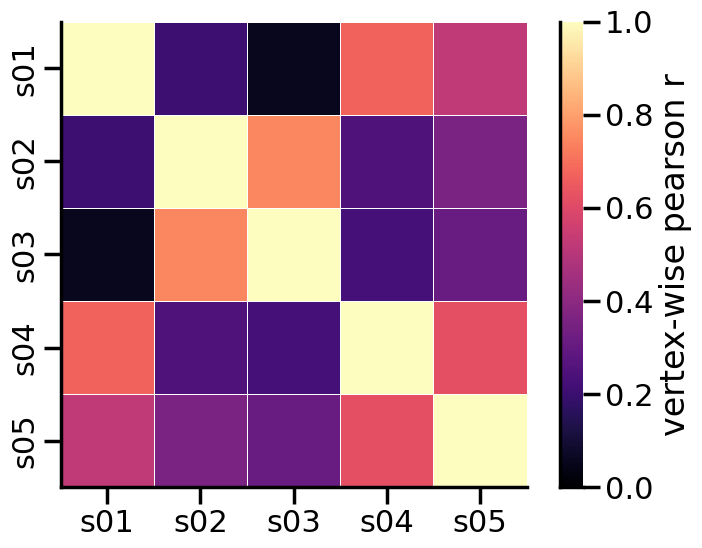

Mean inter-subject vertex-wise r = 0.396
Saved: /Users/atlas/share_psulewski/psulewski/pyavs/source_rsa_figures/model-resnet50_ecoset_crop_layer-layer3/intersubject_rsa_correlation.png


In [73]:
from itertools import combinations

n = len(stcs)
corr_matrix = np.full((n, n), np.nan)

for i, j in combinations(range(n), 2):
    a = stcs[i].data.ravel()
    b = stcs[j].data.ravel()
    r = np.corrcoef(a, b)[0, 1]
    corr_matrix[i, j] = r
    corr_matrix[j, i] = r

np.fill_diagonal(corr_matrix, 1.0)

# ── Plot ─────────────────────────────────────────────────────────────────────
plt.figure(figsize=(8, 6))
sns.heatmap(
    corr_matrix,
    xticklabels=[f's{s:02d}' for s in loaded_subjects],
    yticklabels=[f's{s:02d}' for s in loaded_subjects],
    vmin=0.0, vmax=1.0,
    cmap='magma',
    square=True,
    cbar_kws={'label': 'vertex-wise pearson r'},
    linewidths=0.5,
)
sns.despine()
plt.tight_layout()

fpath = os.path.join(output_dir, 'intersubject_rsa_correlation')
for ext in ('png', 'pdf'):
    plt.savefig(f'{fpath}.{ext}', dpi=300, bbox_inches='tight',
                facecolor='white', edgecolor='none')
plt.show()

off_diag = corr_matrix[np.triu_indices(n, k=1)]
print(f'Mean inter-subject vertex-wise r = {np.nanmean(off_diag):.3f}')
print(f'Saved: {fpath}.png')

## Winner-Take-All Layer Map

For each vertex, the layer with the highest group-average RSA value wins.
Produces a categorical brain map showing the spatial distribution of layer preference.

In [87]:
# ── Load all layers per subject ───────────────────────────────────────────────
print(f'Loading RSA STCs for layers: {layers}\n')

# all_layers_stcs[layer] = list of per-subject STCs (only subjects with all layers)
all_layers_stcs = {lyr: [] for lyr in layers}
wta_loaded_subjects = []

for sub in subjects:
    sub_stcs = load_subject_all_layers_stcs(sub, rsa_dir, model_name, layers)
    if all(sub_stcs[lyr] is not None for lyr in layers):
        for lyr in layers:
            all_layers_stcs[lyr].append(sub_stcs[lyr])
        wta_loaded_subjects.append(sub)
    else:
        missing = [lyr for lyr in layers if sub_stcs[lyr] is None]
        print(f'  sub-{sub:02d}: skipping (missing layers: {missing})')

print(f'\nSubjects with all layers: {wta_loaded_subjects} (n={len(wta_loaded_subjects)})')

Loading RSA STCs for layers: ['layer1', 'layer2', 'layer3', 'layer4', 'avgpool']

  sub-01: 20484 vertices, r range [-0.019, 0.591]
  sub-01: 20484 vertices, r range [-0.023, 0.519]
  sub-01: 20484 vertices, r range [-0.024, 0.485]
  sub-01: 20484 vertices, r range [-0.020, 0.382]
  sub-01: skipping (missing layers: ['layer4'])
  sub-02: 20484 vertices, r range [-0.014, 0.480]
  sub-02: 20484 vertices, r range [0.000, 0.493]
  sub-02: 20484 vertices, r range [-0.005, 0.532]
  sub-02: 20484 vertices, r range [-0.014, 0.412]
  sub-02: skipping (missing layers: ['layer4'])
  sub-03: 20484 vertices, r range [-0.013, 0.450]
  sub-03: 20484 vertices, r range [-0.008, 0.504]
  sub-03: 20484 vertices, r range [-0.016, 0.571]
  sub-03: 20484 vertices, r range [-0.024, 0.400]
  sub-03: skipping (missing layers: ['layer4'])
  sub-04: 20484 vertices, r range [-0.004, 0.408]
  sub-04: 20484 vertices, r range [-0.011, 0.345]
  sub-04: 20484 vertices, r range [-0.000, 0.495]
  sub-04: 20484 vertices,

WTA based on 4 subjects — majority vote per vertex

Winner-take-all vertex counts:
  layer1: 725 vertices (3.5%)
  layer2: 263 vertices (1.3%)
  layer3: 12854 vertices (62.8%)
  avgpool: 6642 vertices (32.4%)

Generating WTA brain plots...

    Saved: group_wta_pial_lateral.png
    Saved: group_wta_pial_medial.png
WTA brain plots done.


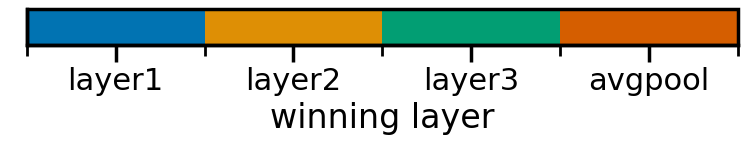

WTA colorbar saved to /Users/atlas/share_psulewski/psulewski/pyavs/source_rsa_figures/model-resnet50_ecoset_crop_wta


In [84]:
# ── Compute WTA via per-subject argmax + majority vote ────────────────────────
wta_stc, winner_counts, win_counts = compute_wta_stc(all_layers_stcs, layers)

print(f'WTA based on {len(wta_loaded_subjects)} subjects — majority vote per vertex\n')
print('Winner-take-all vertex counts:')
total_verts = wta_stc.data.size
for lyr, count in winner_counts.items():
    print(f'  {lyr}: {count} vertices ({100*count/total_verts:.1f}%)')

# ── Build discrete colormap (one color per layer) ─────────────────────────────
import matplotlib.colors as mcolors

n_layers = len(layers)
palette = sns.color_palette('colorblind', n_layers)
cmap_wta = mcolors.ListedColormap(palette, name='wta_layers')

wta_vmin = 0
wta_vmid = (n_layers - 1) / 2
wta_vmax = n_layers - 1

# ── Brain plots ───────────────────────────────────────────────────────────────
print('\nGenerating WTA brain plots...\n')

wta_output_dir = os.path.join(share_dir, 'pyavs', 'source_rsa_figures',
                              f'model-{model_name}_wta')
os.makedirs(wta_output_dir, exist_ok=True)

for surface in surfaces:
    for view in views:
        fname = f'group_wta_{surface}_{view}'
        save_path = os.path.join(wta_output_dir, fname)
        try:
            brain = plot_brain(
                stc=wta_stc,
                surface=surface, view=view,
                subjects_dir=subjects_dir, morph_to=morph_to,
                colormap=cmap_wta,
                vmin=wta_vmin, vmid=wta_vmid, vmax=wta_vmax,
                save_path=save_path,
            )
        except Exception as e:
            print(f'  ERROR ({surface}, {view}): {e}')

print('WTA brain plots done.')

# ── Discrete colorbar ─────────────────────────────────────────────────────────
plt.figure(figsize=(8, 6))
ax = plt.gca()

bounds = np.arange(n_layers + 1) - 0.5
norm = mcolors.BoundaryNorm(bounds, cmap_wta.N)
sm = plt.cm.ScalarMappable(cmap=cmap_wta, norm=norm)
sm.set_array([])

cbar = plt.colorbar(sm, ax=ax, orientation='horizontal', ticks=range(n_layers))
cbar.ax.set_xticklabels(layers)
cbar.set_label('winning layer')
ax.set_visible(False)

sns.despine()
plt.tight_layout()

for ext in ('png', 'pdf'):
    fpath = os.path.join(wta_output_dir, f'colorbar_wta.{ext}')
    plt.savefig(fpath, dpi=300, bbox_inches='tight',
                facecolor='white', edgecolor='none')
plt.show()
print(f'WTA colorbar saved to {wta_output_dir}')